1. Simulate the forward diffusion process by writing a Python function that takes a grayscale image (use any small PNG or JPEG) and adds Gaussian noise to it for 10 steps, saving each noisy image to disk.

In [ ]:
import cv2
import numpy as np

def forward_diffusion(image_path, steps=10):
    # Load grayscale image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Image not found!")
        return

    current_img = img.copy()

    # Save original image
    cv2.imwrite("step_0_original.jpg", current_img)

    for step in range(1, steps + 1):

        # Generate Gaussian noise
        noise = np.random.normal(0, 25, current_img.shape)

        # Add noise to image
        noisy_img = current_img + noise

        # Limit pixel values between 0 and 255
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

        # Save noisy image
        cv2.imwrite(f"step_{step}.jpg", noisy_img)

        current_img = noisy_img

    print("Forward diffusion completed successfully!")

# Example usage
forward_diffusion("/content/images (2).jpg")

Forward diffusion completed successfully!


2. Write a Python script that takes a noisy image and applies a simple denoising filter (like median blur or Gaussian blur) to approximate the reverse diffusion process, then compare the denoised output visually with the original image.<br><br><em><strong>Hint:</strong> Use OpenCV's cv2.medianBlur() or cv2.GaussianBlur() for denoising.</em>

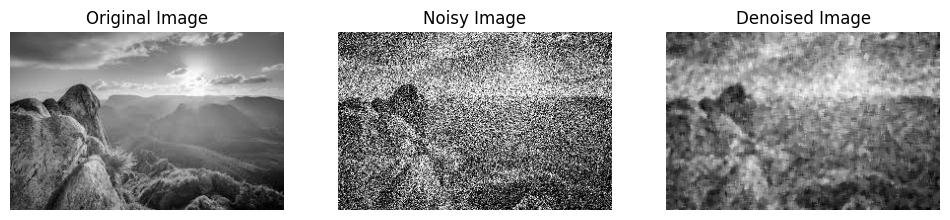

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load original image
original = cv2.imread("/content/images (2).jpg", cv2.IMREAD_GRAYSCALE)

# Load noisy image (generated from Question 1)
noisy = cv2.imread("step_10.jpg", cv2.IMREAD_GRAYSCALE)

# Apply Median Blur for denoising
denoised = cv2.medianBlur(noisy, 5)

# Save denoised image
cv2.imwrite("denoised.jpg", denoised)

# Display comparison
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(original, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised Image")
plt.axis("off")

plt.show()

3.Use the Stable Diffusion web demo (https://stablediffusionweb.com/ or similar) to generate an image from the text prompt: 'A futuristic cricket stadium during IPL finals, night view, neon lights'. Save the generated image and write 2-3 lines describing how the AI interpreted your prompt.

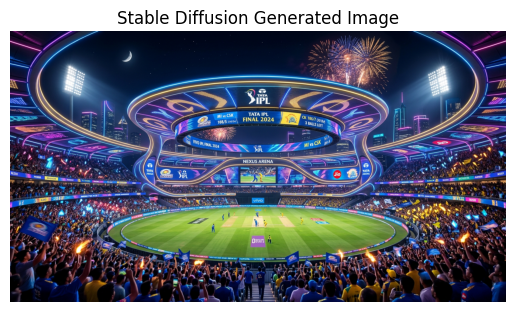

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Firefly_Gemini Flash_A futuristic cricket stadium during IPL finals, night view, neon lights 243122.png")

# BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Stable Diffusion Generated Image")
plt.show()

The AI generated a modern cricket stadium with futuristic architecture and bright neon lights. The scene was set at night during an IPL final match, with a vibrant atmosphere and a large crowd of spectators. The model successfully interpreted the concepts of cricket, futurism, and night-time lighting from the prompt.

4.Research and list two real-world apps or websites (other than art generators) that use diffusion models for image inpainting or super-resolution. For each, briefly describe the user scenario where diffusion is applied.


| App/Website     | Use of Diffusion Model                                                              | User Scenario                                                                                                                                      |
| --------------- | ----------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| Adobe Photoshop | Uses diffusion-based image inpainting to fill missing or removed parts of an image. | A user removes an unwanted object or person from a photo. The AI automatically generates realistic background content to replace the removed area. |
| Remini          | Uses AI and diffusion-based super-resolution techniques to enhance image quality.   | A user uploads an old or blurry photo. The AI increases resolution, sharpens details, and improves overall image quality.                          |


5.List two possible risks or ethical concerns when using text-to-image models like Stable Diffusion for social media content, and suggest one way developers can reduce each risk.


1. Deepfakes and Misinformation

Text-to-image models can generate realistic fake images of people, events, or news. These images may be shared on social media and can mislead people or spread false information. Developers can reduce this risk by adding watermarks or labels that identify AI-generated content.

2. Copyright and Intellectual Property Issues

AI models may create images that closely resemble copyrighted artwork or designs without permission. This can lead to legal and ethical concerns regarding ownership of creative content. Developers can reduce this risk by using licensed training data and implementing copyright protection measures.